In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

In [3]:
import timm

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
DATASET_PATH = "ecg_images"

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [7]:
full_dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=train_transform)

train_size = int(0.7 * len(full_dataset))
test_size = len(full_dataset) - train_size

In [8]:
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes
print("Classes:", class_names)

Classes: ['Fusion', 'Normal', 'Others', 'Supraventricular', 'Ventricular']


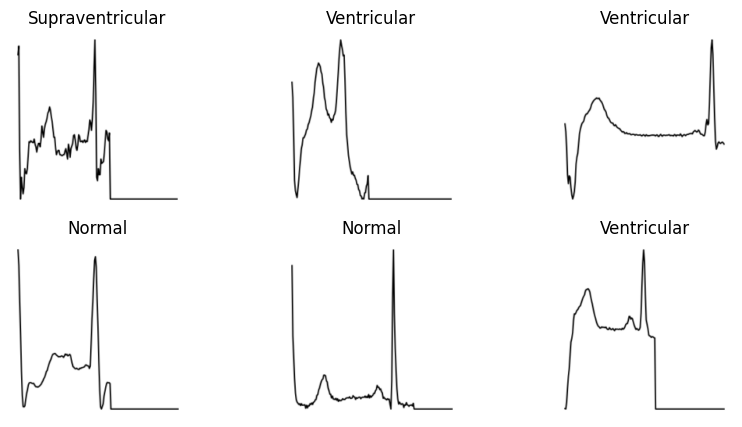

In [9]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.show()

In [10]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_model(model, train_loader, val_loader, epochs=20):
    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.3
    )

    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    patience = 7
    counter = 0

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

        val_loss /= len(val_loader.dataset)

        # Scheduler step
        scheduler.step(val_loss)

        # ===== PRINT =====
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # ===== EARLY STOPPING =====
        if counter >= patience:
            print(" Early stopping triggered")
            break

    print(f"\n Training Finished. Best Val Loss: {best_val_loss:.4f}")
    return model


def evaluate_model(model, test_loader):
    model.to(device)
    model.eval()

    preds, true = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            true.extend(labels.numpy())

    acc = accuracy_score(true, preds)
    prec = precision_score(true, preds, average='weighted')
    rec = recall_score(true, preds, average='weighted')
    f1 = f1_score(true, preds, average='weighted')

    print("\n📊 Evaluation Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return acc, prec, rec, f1

# EfficientNet-B0

In [11]:
effnet_b0 = timm.create_model('efficientnet_b0', pretrained=True, num_classes=5)

effnet_b0 = train_model(effnet_b0, train_loader, test_loader)

Epoch 1/20 | LR: 0.000100 | Train Loss: 1.0087 | Val Loss: 2.3811
Epoch 2/20 | LR: 0.000100 | Train Loss: 0.1448 | Val Loss: 0.9100
Epoch 3/20 | LR: 0.000100 | Train Loss: 0.0525 | Val Loss: 0.4496
Epoch 4/20 | LR: 0.000100 | Train Loss: 0.0183 | Val Loss: 0.5325
Epoch 5/20 | LR: 0.000100 | Train Loss: 0.0146 | Val Loss: 0.5537
Epoch 6/20 | LR: 0.000100 | Train Loss: 0.0109 | Val Loss: 0.5307
Epoch 7/20 | LR: 0.000030 | Train Loss: 0.0090 | Val Loss: 0.4504
Epoch 8/20 | LR: 0.000030 | Train Loss: 0.0058 | Val Loss: 0.4237
Epoch 9/20 | LR: 0.000030 | Train Loss: 0.0039 | Val Loss: 0.4257
Epoch 10/20 | LR: 0.000030 | Train Loss: 0.0033 | Val Loss: 0.4230
Epoch 11/20 | LR: 0.000030 | Train Loss: 0.0034 | Val Loss: 0.4390
Epoch 12/20 | LR: 0.000030 | Train Loss: 0.0032 | Val Loss: 0.4290
Epoch 13/20 | LR: 0.000030 | Train Loss: 0.0032 | Val Loss: 0.4359
Epoch 14/20 | LR: 0.000009 | Train Loss: 0.0028 | Val Loss: 0.4356
Epoch 15/20 | LR: 0.000009 | Train Loss: 0.0023 | Val Loss: 0.4270
Epoc

In [12]:
effnet_b0_metrics = evaluate_model(effnet_b0, test_loader)


📊 Evaluation Metrics:
Accuracy : 0.8907
Precision: 0.8962
Recall   : 0.8907
F1 Score : 0.8918


# EFficientNetB4

In [13]:
effnet_b3 = timm.create_model('efficientnet_b4', pretrained=True, num_classes=5)

effnet_b3 = train_model(effnet_b3, train_loader, test_loader)

Epoch 1/20 | LR: 0.000100 | Train Loss: 1.0509 | Val Loss: 2.2246
Epoch 2/20 | LR: 0.000100 | Train Loss: 0.3732 | Val Loss: 0.6464
Epoch 3/20 | LR: 0.000100 | Train Loss: 0.1655 | Val Loss: 0.5700
Epoch 4/20 | LR: 0.000100 | Train Loss: 0.0761 | Val Loss: 0.6721
Epoch 5/20 | LR: 0.000100 | Train Loss: 0.0395 | Val Loss: 0.4719
Epoch 6/20 | LR: 0.000100 | Train Loss: 0.0201 | Val Loss: 0.4731
Epoch 7/20 | LR: 0.000100 | Train Loss: 0.0146 | Val Loss: 0.4685
Epoch 8/20 | LR: 0.000100 | Train Loss: 0.0096 | Val Loss: 0.5028
Epoch 9/20 | LR: 0.000100 | Train Loss: 0.0086 | Val Loss: 0.5037
Epoch 10/20 | LR: 0.000100 | Train Loss: 0.0062 | Val Loss: 0.5213
Epoch 11/20 | LR: 0.000030 | Train Loss: 0.0060 | Val Loss: 0.5440
Epoch 12/20 | LR: 0.000030 | Train Loss: 0.0038 | Val Loss: 0.5215
Epoch 13/20 | LR: 0.000030 | Train Loss: 0.0029 | Val Loss: 0.5375
Epoch 14/20 | LR: 0.000030 | Train Loss: 0.0032 | Val Loss: 0.5435
Epoch 15/20 | LR: 0.000009 | Train Loss: 0.0026 | Val Loss: 0.5357
Epoc

In [14]:
effnet_b3_metrics = evaluate_model(effnet_b3, test_loader)


📊 Evaluation Metrics:
Accuracy : 0.8653
Precision: 0.8695
Recall   : 0.8653
F1 Score : 0.8662


# ViT

In [15]:
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=5)

vit_model = train_model(vit_model, train_loader, test_loader)

Epoch 1/20 | LR: 0.000100 | Train Loss: 1.6976 | Val Loss: 1.6650
Epoch 2/20 | LR: 0.000100 | Train Loss: 1.6267 | Val Loss: 1.6355
Epoch 3/20 | LR: 0.000100 | Train Loss: 1.5933 | Val Loss: 1.4192
Epoch 4/20 | LR: 0.000100 | Train Loss: 1.1109 | Val Loss: 0.8354
Epoch 5/20 | LR: 0.000100 | Train Loss: 0.7806 | Val Loss: 0.7022
Epoch 6/20 | LR: 0.000100 | Train Loss: 0.5540 | Val Loss: 0.5816
Epoch 7/20 | LR: 0.000100 | Train Loss: 0.4325 | Val Loss: 0.5814
Epoch 8/20 | LR: 0.000100 | Train Loss: 0.2813 | Val Loss: 0.5145
Epoch 9/20 | LR: 0.000100 | Train Loss: 0.2032 | Val Loss: 0.5029
Epoch 10/20 | LR: 0.000100 | Train Loss: 0.1587 | Val Loss: 0.5966
Epoch 11/20 | LR: 0.000100 | Train Loss: 0.1305 | Val Loss: 0.6789
Epoch 12/20 | LR: 0.000100 | Train Loss: 0.1403 | Val Loss: 0.8009
Epoch 13/20 | LR: 0.000030 | Train Loss: 0.0906 | Val Loss: 0.6003
Epoch 14/20 | LR: 0.000030 | Train Loss: 0.0227 | Val Loss: 0.6430
Epoch 15/20 | LR: 0.000030 | Train Loss: 0.0028 | Val Loss: 0.6951
Epoc

In [16]:
vit_metrics = evaluate_model(vit_model, test_loader)


📊 Evaluation Metrics:
Accuracy : 0.8680
Precision: 0.8756
Recall   : 0.8680
F1 Score : 0.8704


# ConvNeXt

In [17]:
convnext = timm.create_model('convnext_base', pretrained=True, num_classes=5)

convnext = train_model(convnext, train_loader, test_loader)

Epoch 1/20 | LR: 0.000100 | Train Loss: 0.7937 | Val Loss: 0.4430
Epoch 2/20 | LR: 0.000100 | Train Loss: 0.3138 | Val Loss: 0.2608
Epoch 3/20 | LR: 0.000100 | Train Loss: 0.1606 | Val Loss: 0.2972
Epoch 4/20 | LR: 0.000100 | Train Loss: 0.1005 | Val Loss: 0.3206
Epoch 5/20 | LR: 0.000100 | Train Loss: 0.0596 | Val Loss: 0.2665
Epoch 6/20 | LR: 0.000030 | Train Loss: 0.0353 | Val Loss: 0.4524
Epoch 7/20 | LR: 0.000030 | Train Loss: 0.0148 | Val Loss: 0.2608
Epoch 8/20 | LR: 0.000030 | Train Loss: 0.0030 | Val Loss: 0.2917
Epoch 9/20 | LR: 0.000030 | Train Loss: 0.0016 | Val Loss: 0.2772
Epoch 10/20 | LR: 0.000009 | Train Loss: 0.0013 | Val Loss: 0.2784
Epoch 11/20 | LR: 0.000009 | Train Loss: 0.0010 | Val Loss: 0.2796
Epoch 12/20 | LR: 0.000009 | Train Loss: 0.0010 | Val Loss: 0.2799
Epoch 13/20 | LR: 0.000009 | Train Loss: 0.0009 | Val Loss: 0.2814
Epoch 14/20 | LR: 0.000003 | Train Loss: 0.0009 | Val Loss: 0.2826
Epoch 15/20 | LR: 0.000003 | Train Loss: 0.0008 | Val Loss: 0.2828
Epoc

In [18]:
convnext_metrics = evaluate_model(convnext, test_loader)


📊 Evaluation Metrics:
Accuracy : 0.9280
Precision: 0.9324
Recall   : 0.9280
F1 Score : 0.9282


# Federated Learning

In [19]:
import flwr as fl

In [20]:
dataset_size = len(full_dataset)
client_size = dataset_size // 2

In [21]:
client1_data, client2_data = random_split(full_dataset, [client_size, dataset_size - client_size])

train_loader_c1 = DataLoader(client1_data, batch_size=32, shuffle=True)
train_loader_c2 = DataLoader(client2_data, batch_size=32, shuffle=True)

In [22]:
class ECGClient(fl.client.NumPyClient):
    def __init__(self, model, train_loader):
        self.model = model.to(device)
        self.train_loader = train_loader

    def get_parameters(self, config):
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def set_parameters(self, parameters):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = {k: torch.tensor(v) for k, v in params_dict}
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train_model(self.model, self.train_loader, test_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        acc, prec, rec, f1 = evaluate_model(self.model, test_loader)

        return float(1 - acc), len(test_loader.dataset), {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
        }

In [23]:
def client_fn(cid: str):
    model = timm.create_model('convnext_base', pretrained=True, num_classes=5)

    if cid == "0":
        return ECGClient(model, train_loader_c1)
    else:
        return ECGClient(model, train_loader_c2)

In [24]:
fl_metrics_history = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

In [25]:
def agg_metrics(metrics):
    acc = sum(n*m["accuracy"] for n,m in metrics)/sum(n for n,_ in metrics)
    prec = sum(n*m["precision"] for n,m in metrics)/sum(n for n,_ in metrics)
    rec = sum(n*m["recall"] for n,m in metrics)/sum(n for n,_ in metrics)
    f1 = sum(n*m["f1"] for n,m in metrics)/sum(n for n,_ in metrics)

    # STORE METRICS
    fl_metrics_history["accuracy"].append(acc)
    fl_metrics_history["precision"].append(prec)
    fl_metrics_history["recall"].append(rec)
    fl_metrics_history["f1"].append(f1)

    print("\n🌐 Global Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [26]:
global_model = timm.create_model('convnext_base', pretrained=False, num_classes=5).to(device)

final_parameters = None

In [27]:
from flwr.common import parameters_to_ndarrays

class SaveFinalModelStrategy(fl.server.strategy.FedAvg):
    def aggregate_fit(self, rnd, results, failures):
        global final_parameters

        aggregated_parameters, aggregated_metrics = super().aggregate_fit(rnd, results, failures)

        if aggregated_parameters is not None:
            final_parameters = aggregated_parameters  # store latest weights

        return aggregated_parameters, aggregated_metrics

In [28]:
strategy = SaveFinalModelStrategy(
    evaluate_metrics_aggregation_fn=agg_metrics
)

In [29]:
fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=2,
    config=fl.server.ServerConfig(num_rounds=3),
    strategy=strategy,
)

INFO flwr 2026-03-25 20:48:40,599 | app.py:145 | Starting Flower simulation, config: ServerConfig(num_rounds=3, round_timeout=None)
2026-03-25 20:48:42,925	INFO worker.py:1529 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
INFO flwr 2026-03-25 20:48:44,336 | app.py:179 | Flower VCE: Ray initialized with resources: {'memory': 32645232231.0, 'CPU': 24.0, 'object_store_memory': 16322616115.0, 'GPU': 1.0, 'node:127.0.0.1': 1.0}
INFO flwr 2026-03-25 20:48:44,336 | server.py:86 | Initializing global parameters
INFO flwr 2026-03-25 20:48:44,337 | server.py:270 | Requesting initial parameters from one random client
INFO flwr 2026-03-25 20:48:50,116 | server.py:274 | Received initial parameters from one random client
INFO flwr 2026-03-25 20:48:50,116 | server.py:88 | Evaluating initial parameters
INFO flwr 2026-03-25 20:48:50,117 | server.py:101 | FL starting
DEBUG flwr 2026-03-25 20:48:50,118 | server.py:215 | fit_round 1: strategy sampled 2 clients (out of 2)


(launch_and_fit pid=30032) Epoch 1/1 | LR: 0.000100 | Train Loss: 0.8720 | Val Loss: 0.4556
(launch_and_fit pid=30032) 
(launch_and_fit pid=30032)  Training Finished. Best Val Loss: inf
(launch_and_fit pid=36360) Epoch 1/1 | LR: 0.000100 | Train Loss: 0.8801 | Val Loss: 0.3136
(launch_and_fit pid=36360) 
(launch_and_fit pid=36360)  Training Finished. Best Val Loss: inf


DEBUG flwr 2026-03-25 21:00:36,041 | server.py:229 | fit_round 1 received 2 results and 0 failures
WARNING flwr 2026-03-25 21:00:36,734 | fedavg.py:242 | No fit_metrics_aggregation_fn provided
DEBUG flwr 2026-03-25 21:00:36,774 | server.py:165 | evaluate_round 1: strategy sampled 2 clients (out of 2)
DEBUG flwr 2026-03-25 21:00:43,190 | server.py:179 | evaluate_round 1 received 2 results and 0 failures
DEBUG flwr 2026-03-25 21:00:43,191 | server.py:215 | fit_round 2: strategy sampled 2 clients (out of 2)


(launch_and_evaluate pid=36360) 
(launch_and_evaluate pid=36360) 📊 Evaluation Metrics:
(launch_and_evaluate pid=36360) Accuracy : 0.8680
(launch_and_evaluate pid=36360) Precision: 0.8897
(launch_and_evaluate pid=36360) Recall   : 0.8680
(launch_and_evaluate pid=36360) F1 Score : 0.8698
(launch_and_evaluate pid=30032) 
(launch_and_evaluate pid=30032) 📊 Evaluation Metrics:
(launch_and_evaluate pid=30032) Accuracy : 0.8680
(launch_and_evaluate pid=30032) Precision: 0.8897
(launch_and_evaluate pid=30032) Recall   : 0.8680
(launch_and_evaluate pid=30032) F1 Score : 0.8698

🌐 Global Metrics:
Accuracy: 0.8680
Precision: 0.8897
Recall: 0.8680
F1: 0.8698
(launch_and_fit pid=36360) Epoch 1/1 | LR: 0.000100 | Train Loss: 0.4605 | Val Loss: 0.3929
(launch_and_fit pid=36360) 
(launch_and_fit pid=36360)  Training Finished. Best Val Loss: inf
(launch_and_fit pid=30032) Epoch 1/1 | LR: 0.000100 | Train Loss: 0.4721 | Val Loss: 0.2924
(launch_and_fit pid=30032) 
(launch_and_fit pid=30032)  Training Fin

DEBUG flwr 2026-03-25 21:25:45,132 | server.py:229 | fit_round 2 received 2 results and 0 failures
DEBUG flwr 2026-03-25 21:25:46,035 | server.py:165 | evaluate_round 2: strategy sampled 2 clients (out of 2)
DEBUG flwr 2026-03-25 21:25:53,841 | server.py:179 | evaluate_round 2 received 2 results and 0 failures
DEBUG flwr 2026-03-25 21:25:53,842 | server.py:215 | fit_round 3: strategy sampled 2 clients (out of 2)


(launch_and_evaluate pid=36360) 
(launch_and_evaluate pid=36360) 📊 Evaluation Metrics:
(launch_and_evaluate pid=36360) Accuracy : 0.9320
(launch_and_evaluate pid=36360) Precision: 0.9372
(launch_and_evaluate pid=36360) Recall   : 0.9320
(launch_and_evaluate pid=36360) F1 Score : 0.9320

🌐 Global Metrics:
Accuracy: 0.9320
Precision: 0.9372
Recall: 0.9320
F1: 0.9320
(launch_and_evaluate pid=30032) 
(launch_and_evaluate pid=30032) 📊 Evaluation Metrics:
(launch_and_evaluate pid=30032) Accuracy : 0.9320
(launch_and_evaluate pid=30032) Precision: 0.9372
(launch_and_evaluate pid=30032) Recall   : 0.9320
(launch_and_evaluate pid=30032) F1 Score : 0.9320
(launch_and_fit pid=36360) Epoch 1/1 | LR: 0.000100 | Train Loss: 0.2832 | Val Loss: 0.1978
(launch_and_fit pid=36360) 
(launch_and_fit pid=36360)  Training Finished. Best Val Loss: inf
(launch_and_fit pid=30032) Epoch 1/1 | LR: 0.000100 | Train Loss: 0.3178 | Val Loss: 0.1836
(launch_and_fit pid=30032) 
(launch_and_fit pid=30032)  Training Fin

DEBUG flwr 2026-03-25 21:50:55,541 | server.py:229 | fit_round 3 received 2 results and 0 failures
DEBUG flwr 2026-03-25 21:50:56,524 | server.py:165 | evaluate_round 3: strategy sampled 2 clients (out of 2)
DEBUG flwr 2026-03-25 21:51:04,713 | server.py:179 | evaluate_round 3 received 2 results and 0 failures
INFO flwr 2026-03-25 21:51:04,714 | server.py:144 | FL finished in 3734.597247700003
INFO flwr 2026-03-25 21:51:04,743 | app.py:202 | app_fit: losses_distributed [(1, 0.132), (2, 0.06799999999999995), (3, 0.04400000000000004)]
INFO flwr 2026-03-25 21:51:04,744 | app.py:203 | app_fit: metrics_distributed {'accuracy': [(1, 0.868), (2, 0.932), (3, 0.956)], 'precision': [(1, 0.8897474299347294), (2, 0.9372171705483779), (3, 0.9582506571872885)], 'recall': [(1, 0.868), (2, 0.932), (3, 0.956)], 'f1': [(1, 0.8697590496801796), (2, 0.9319951509880103), (3, 0.9563324158961647)]}
INFO flwr 2026-03-25 21:51:04,744 | app.py:204 | app_fit: losses_centralized []
INFO flwr 2026-03-25 21:51:04,7

(launch_and_evaluate pid=30032) 
(launch_and_evaluate pid=30032) 📊 Evaluation Metrics:
(launch_and_evaluate pid=30032) Accuracy : 0.9560
(launch_and_evaluate pid=30032) Precision: 0.9583
(launch_and_evaluate pid=30032) Recall   : 0.9560
(launch_and_evaluate pid=30032) F1 Score : 0.9563

🌐 Global Metrics:
Accuracy: 0.9560
Precision: 0.9583
Recall: 0.9560
F1: 0.9563


History (loss, distributed):
	round 1: 0.132
	round 2: 0.06799999999999995
	round 3: 0.04400000000000004
History (metrics, distributed):
{'accuracy': [(1, 0.868), (2, 0.932), (3, 0.956)], 'precision': [(1, 0.8897474299347294), (2, 0.9372171705483779), (3, 0.9582506571872885)], 'recall': [(1, 0.868), (2, 0.932), (3, 0.956)], 'f1': [(1, 0.8697590496801796), (2, 0.9319951509880103), (3, 0.9563324158961647)]}

# Comparison

In [31]:
import pandas as pd

data = {
    "Model": ["EffNet", "ViT", "ConvNeXt", "FL"],
    "Accuracy": [
        effnet_b3_metrics[0],
        vit_metrics[0],
        convnext_metrics[0],
        fl_metrics_history["accuracy"][-1]
    ],
    "Precision": [
        effnet_b3_metrics[1],
        vit_metrics[1],
        convnext_metrics[1],
        fl_metrics_history["precision"][-1]
    ],
    "Recall": [
        effnet_b3_metrics[2],
        vit_metrics[2],
        convnext_metrics[2],
        fl_metrics_history["recall"][-1]
    ],
    "F1": [
        effnet_b3_metrics[3],
        vit_metrics[3],
        convnext_metrics[3],
        fl_metrics_history["f1"][-1]
    ]
}

df = pd.DataFrame(data)

In [32]:
df

,Model,Accuracy,Precision,Recall,F1
0,EffNet,0.865333,0.869513,0.865333,0.866200
1,ViT,0.868000,0.875598,0.868000,0.870362
2,ConvNeXt,0.928000,0.932382,0.928000,0.928158
3,FL,0.956000,0.958251,0.956000,0.956332


# Modelling

In [30]:
from flwr.common import parameters_to_ndarrays

# Convert FL weights → PyTorch
ndarrays = parameters_to_ndarrays(final_parameters)

params_dict = zip(global_model.state_dict().keys(), ndarrays)
state_dict = {k: torch.tensor(v) for k, v in params_dict}

global_model.load_state_dict(state_dict, strict=True)

# SAVE FINAL MODEL
torch.save(global_model.state_dict(), "models/fl_final_model.pth")

(launch_and_evaluate pid=36360) 
(launch_and_evaluate pid=36360) 📊 Evaluation Metrics:
(launch_and_evaluate pid=36360) Accuracy : 0.9560
(launch_and_evaluate pid=36360) Precision: 0.9583
(launch_and_evaluate pid=36360) Recall   : 0.9560
(launch_and_evaluate pid=36360) F1 Score : 0.9563


In [33]:
torch.save(convnext.state_dict(), "models/convnext.pth")

# Graph

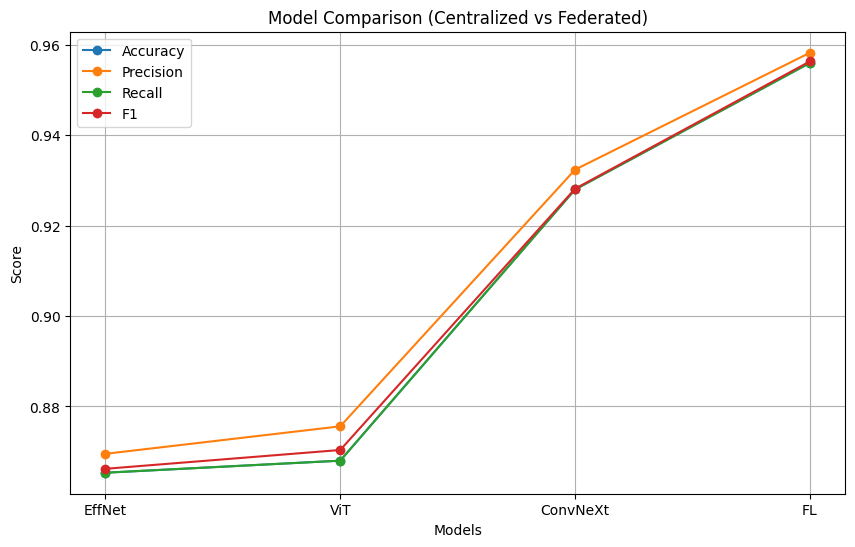

In [34]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1"]

plt.figure(figsize=(10,6))

for metric in metrics:
    plt.plot(df["Model"], df[metric], marker='o', label=metric)

plt.title("Model Comparison (Centralized vs Federated)")
plt.xlabel("Models")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
import pandas as pd

# Number of FL rounds
n_rounds = len(fl_metrics_history["accuracy"])

# Repeat centralized metrics to match FL rounds
data = {
    "EffNet": [effnet_b3_metrics[0]] * n_rounds,
    "ViT": [vit_metrics[0]] * n_rounds,
    "ConvNeXt": [convnext_metrics[0]] * n_rounds,
    "FL": fl_metrics_history["accuracy"]  # real variation
}

df_box = pd.DataFrame(data)
print(df_box.head())

     EffNet    ViT  ConvNeXt     FL
0  0.865333  0.868     0.928  0.868
1  0.865333  0.868     0.928  0.932
2  0.865333  0.868     0.928  0.956


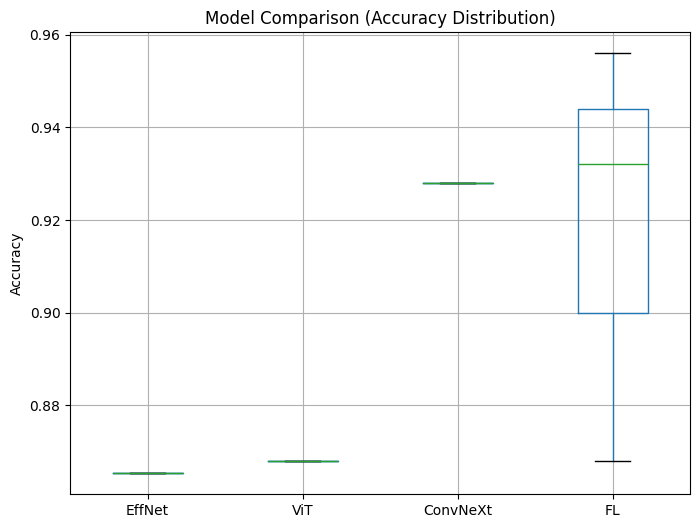

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df_box.boxplot()

plt.title("Model Comparison (Accuracy Distribution)")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

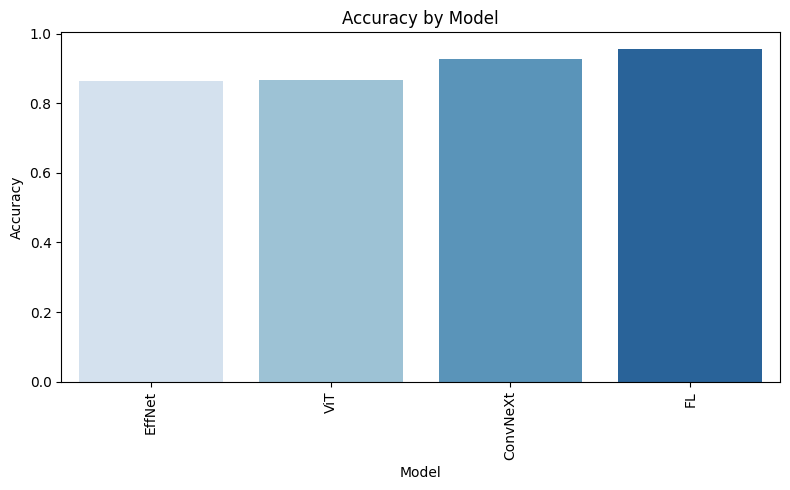

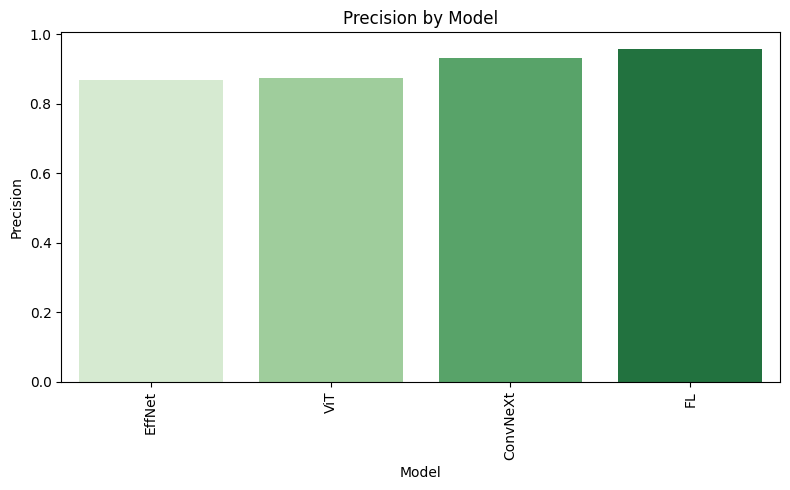

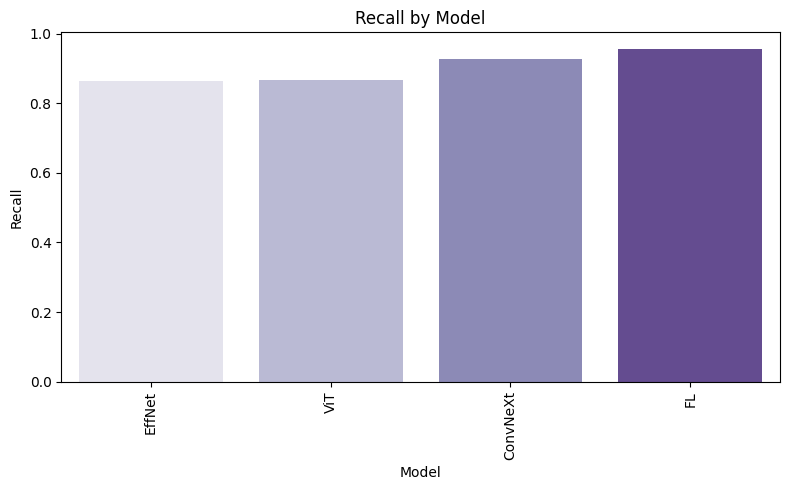

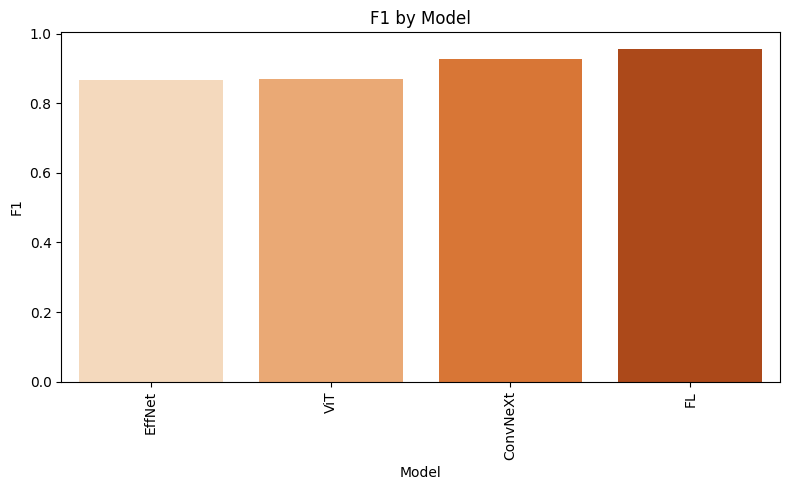

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

palettes = {
    'Accuracy': 'Blues',
    'Precision': 'Greens',
    'Recall': 'Purples',
    'F1': 'Oranges'
}

for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='Model', y=metric, palette=palettes[metric])
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()